C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_25544\1513610888.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


Slope: [[2.25542015]]
Intercept: [-2.08957753]


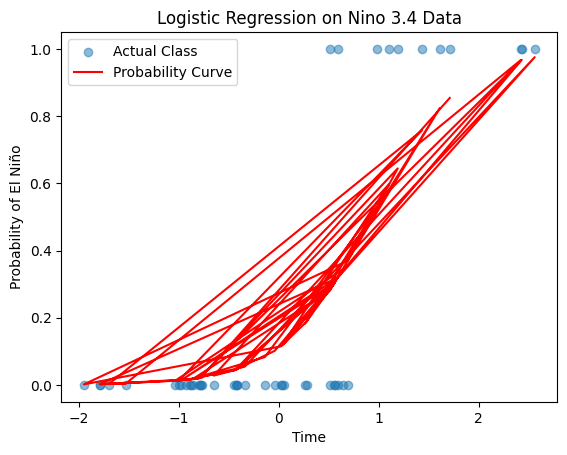

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Load the data
file_path = "nino-3.4_7924_noaa.txt"
data = pd.read_csv(file_path, delim_whitespace=True, header=None)

# Column 0 = time (year), Column 1 = Nino index
X = data.iloc[:, 0].values.reshape(-1, 1)

# Convert continuous values into binary classes
y_continuous = data.iloc[:, 1].values
y = (y_continuous > 0.5).astype(int)   # 1 = El Niño, 0 = Normal/La Niña

# Create Logistic Regression Model
model = LogisticRegression()
model.fit(X, y)

# Predictions (probabilities)
y_prob = model.predict_proba(X)[:, 1]
y_pred = model.predict(X)

# Print results
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

# Plot
plt.scatter(X, y, label="Actual Class", alpha=0.5)
plt.plot(X, y_prob, color='red', label="Probability Curve")
plt.xlabel("Time")
plt.ylabel("Probability of El Niño")
plt.title("Logistic Regression on Nino 3.4 Data")
plt.legend()
plt.show()

C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_25544\3145932845.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


C:\Users\V.Sree Chaitran\AppData\Local\Temp\ipykernel_25544\226894525.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None)


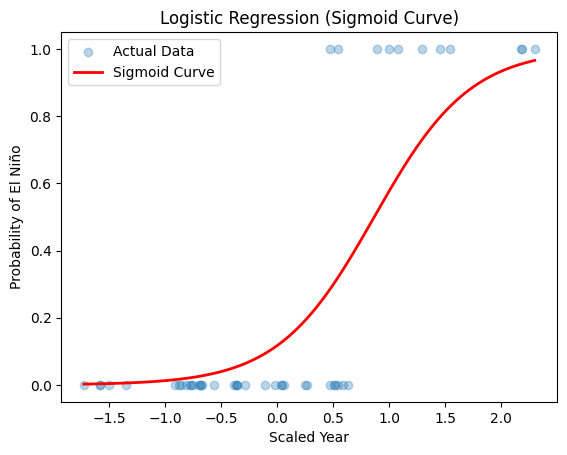

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load data
file_path = "nino-3.4_7924_noaa.txt"
data = pd.read_csv(file_path, delim_whitespace=True, header=None)

# X = Year, y = Nino index
X = data.iloc[:, 0].values.reshape(-1, 1)
y_continuous = data.iloc[:, 1].values

# Convert to binary classification
y = (y_continuous > 0.5).astype(int)

#SCALE X 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
model = LogisticRegression()
model.fit(X_scaled, y)

# Create smooth X for curve
X_test = np.linspace(X_scaled.min(), X_scaled.max(), 500).reshape(-1,1)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Plot
plt.scatter(X_scaled, y, alpha=0.3, label="Actual Data")
plt.plot(X_test, y_prob, color='red', linewidth=2, label="Sigmoid Curve")

plt.xlabel("Scaled Year")
plt.ylabel("Probability of El Niño")
plt.title("Logistic Regression (Sigmoid Curve)")
plt.legend()
plt.show()

Multinomial Logistic Regression Accuracy (%): 84.54545454545455

Confusion Matrix:
 [[27  3  0]
 [ 2 45  5]
 [ 0  7 21]]

Classification Report:
               precision    recall  f1-score   support

          -1       0.93      0.90      0.92        30
           0       0.82      0.87      0.84        52
           1       0.81      0.75      0.78        28

    accuracy                           0.85       110
   macro avg       0.85      0.84      0.84       110
weighted avg       0.85      0.85      0.85       110



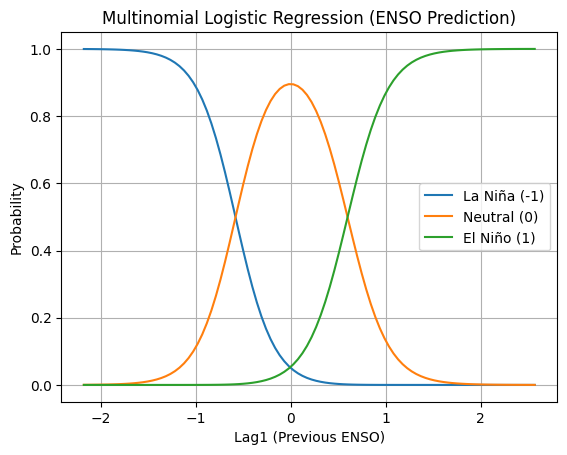

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Load Data
# -----------------------------
file = "nino-3.4_7924_noaa.txt"

# FIXED: use raw string for separator
data = pd.read_csv(file, sep=r'\s+', header=None)

# -----------------------------
# Preprocess Data
# -----------------------------
values = data.values.flatten()

# Remove missing values (-99 or similar)
values = values[values > -90]

df = pd.DataFrame(values, columns=["ENSO"])

# -----------------------------
# Create Lag Features
# -----------------------------
df["lag1"] = df["ENSO"].shift(1)
df["lag2"] = df["ENSO"].shift(2)

df = df.dropna()

# -----------------------------
# Create Target (Multiclass)
# -----------------------------
def classify_enso(x):
    if x > 0.5:
        return 1      # El Niño
    elif x < -0.5:
        return -1     # La Niña
    else:
        return 0      # Neutral

df["Event"] = df["ENSO"].apply(classify_enso)

# -----------------------------
# Features & Labels
# -----------------------------
X = df[["lag1", "lag2"]]
y = df["Event"]

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train Multinomial Model
# -----------------------------
# NOTE: multi_class removed (auto handled)
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
accuracy = accuracy_score(y_test, y_pred) * 100
print("Multinomial Logistic Regression Accuracy (%):", accuracy)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# Probability Visualization
# -----------------------------
lag1_range = np.linspace(df["lag1"].min(), df["lag1"].max(), 100)
lag2_mean = df["lag2"].mean()

X_plot = pd.DataFrame({
    "lag1": lag1_range,
    "lag2": lag2_mean
})

# Get probabilities for all classes
y_prob = model.predict_proba(X_plot)

# -----------------------------
# Plot
# -----------------------------
plt.figure()

# Each column corresponds to a class
# Order depends on model.classes_
for i, cls in enumerate(model.classes_):
    if cls == -1:
        label = "La Niña (-1)"
    elif cls == 0:
        label = "Neutral (0)"
    else:
        label = "El Niño (1)"
    
    plt.plot(lag1_range, y_prob[:, i], label=label)

plt.xlabel("Lag1 (Previous ENSO)")
plt.ylabel("Probability")
plt.title("Multinomial Logistic Regression (ENSO Prediction)")
plt.legend()
plt.grid()

plt.show()